In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../Data/student_information.csv')
df.G1 = df.G1 / 5
df.G2 = df.G2 / 5
df.G3 = df.G3 / 5

In [3]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0.0,11.0,11.0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9.0,11.0,11.0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12.0,13.0,12.0
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14.0,14.0,14.0
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11.0,13.0,13.0


In [4]:
df['studytime'].unique()

array([2, 3, 1, 4])

In [5]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0.0,11.0,11.0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9.0,11.0,11.0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12.0,13.0,12.0
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14.0,14.0,14.0
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11.0,13.0,13.0


In [6]:
def create_performance_class(score):
    if score >= 18:
        return "High"
    elif score >= 12:
        return "Medium"
    else:
        return "Low"
df["performance_class"] = df["G3"].apply(create_performance_class)

In [7]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,performance_class
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,4,0.0,11.0,11.0,Low
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,2,9.0,11.0,11.0,Low
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,6,12.0,13.0,12.0,Medium
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,0,14.0,14.0,14.0,Medium
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,0,11.0,13.0,13.0,Medium


np.int64(75)

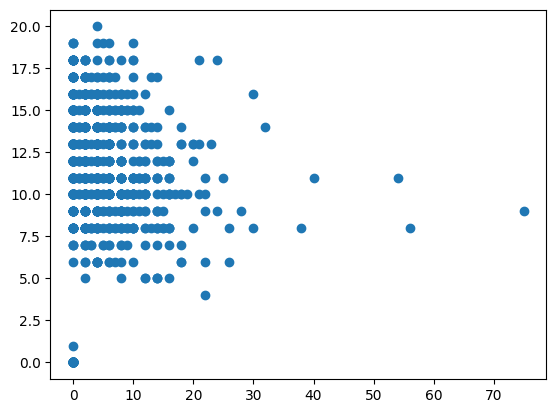

In [8]:
plt.scatter(df.absences, df.G3)
df.absences.max()

In [9]:
X = df.drop(columns=['G3', 'performance_class'], axis=1)
y = df['performance_class']

In [10]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [12]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop='first'))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [13]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [15]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

svc_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
        probability=True,
        random_state=42
    ))
])

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    ))
])

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import label_binarize

In [17]:
def evaluate_model(name, pipeline):
    pipeline.fit(x_train, y_train)

    y_pred = pipeline.predict(x_test)

    print(f"--- {name} ---")

    print("Accuracy:", accuracy_score(y_test, y_pred))

    print(
        "Precision:",
        precision_score(y_test, y_pred, average="weighted")
    )

    print(
        "Recall:",
        recall_score(y_test, y_pred, average="weighted")
    )

    print(
        "F1 Score:",
        f1_score(y_test, y_pred, average="weighted")
    )

    if hasattr(pipeline, "predict_proba"):
        y_proba = pipeline.predict_proba(x_test)

        y_test_bin = label_binarize(
            y_test,
            classes=[0, 1, 2]
        )

        roc_auc = roc_auc_score(
            y_test_bin,
            y_proba,
            multi_class="ovr"
        )

        print("ROC-AUC:", roc_auc)

    print()
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("=" * 50)

In [18]:
evaluate_model("Logistic Regression", lr_pipeline)
evaluate_model("Decision Tree", dt_pipeline)
evaluate_model("Random Forest", rf_pipeline)
evaluate_model("Gradient Boosting", gb_pipeline)
evaluate_model("Support Vector Classifier", svc_pipeline)
evaluate_model("XGBoost", xgb_pipeline)

--- Logistic Regression ---
Accuracy: 0.8949044585987261
Precision: 0.8949018516601756
Recall: 0.8949044585987261
F1 Score: 0.893754481938366
ROC-AUC: 0.9787845416126477

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.50      0.59        10
           1       0.94      0.90      0.92       161
           2       0.86      0.92      0.89       143

    accuracy                           0.89       314
   macro avg       0.84      0.77      0.80       314
weighted avg       0.89      0.89      0.89       314

--- Decision Tree ---
Accuracy: 0.8694267515923567
Precision: 0.8711019579359288
Recall: 0.8694267515923567
F1 Score: 0.8695390001762118
ROC-AUC: 0.8678641466045557

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.70      0.74        10
           1       0.91      0.86      0.89       161
           2       0.84      0.89      0.86       143

    accuracy      

In [19]:
param_grid_xgb_small = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__reg_lambda": [1, 2]
}

In [20]:
from sklearn.model_selection import GridSearchCV

grid_search_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb_small,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2
)

grid_search_xgb.fit(x_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=2, model__n_estimators=100, model__reg_lambda=1, model__subsample=0.8; total time=   0.0s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=2, model__n_estimators=100, model__reg_lambda=1, model__subsample=0.8; total time=   0.0s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=2, model__n_estimators=100, model__reg_lambda=1, model__subsample=0.8; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=2, model__n_estimators=100, model__reg_lambda=1, model__subsample=1.0; total time=   0.0s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=2, model__n_estimators=100, model__reg_lambda=1, model__subsample=0.8; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : 

In [21]:
print("Best Parameters:")
print(grid_search_xgb.best_params_)

print("Best CV F1:")
print(grid_search_xgb.best_score_)

Best Parameters:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__reg_lambda': 1, 'model__subsample': 1.0}
Best CV F1:
0.9217823510538518


In [22]:
best_xgb_model = grid_search_xgb.best_estimator_

y_pred = best_xgb_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1:", f1_score(y_test, y_pred, average="weighted"))

Accuracy: 0.9394904458598726
Precision: 0.9393626896811611
Recall: 0.9394904458598726
F1: 0.9392309090031862


In [23]:
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

        High       0.89      0.80      0.84        10
         Low       0.94      0.96      0.95       161
      Medium       0.94      0.92      0.93       143

    accuracy                           0.94       314
   macro avg       0.92      0.90      0.91       314
weighted avg       0.94      0.94      0.94       314



In [24]:
param_grid_gb = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__subsample": [0.8, 1.0],
    "model__max_features": [None, "sqrt", "log2"]
}

In [25]:
grid_search_gb = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid_gb,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2
)

grid_search_gb.fit(x_train, y_train)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
[CV] END model__learning_rate=0.03, model__max_depth=2, model__max_features=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100, model__subsample=1.0; total time=   0.2s
[CV] END model__learning_rate=0.03, model__max_depth=2, model__max_features=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100, model__subsample=0.8; total time=   0.2s
[CV] END model__learning_rate=0.03, model__max_depth=2, model__max_features=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100, model__subsample=0.8; total time=   0.3s
[CV] END model__learning_rate=0.03, model__max_depth=2, model__max_features=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100, model__subsample=0.8; total time=   0.2s
[CV] END model__learning_rate=0.03, model__max_depth=2, model__max_features=None, model__min_samples_leaf=1, model__min_samp

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__max_features': [None, 'sqrt', ...], 'model__min_samples_leaf': [1, 2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : th

In [26]:
print(grid_search_gb.best_params_)
print(grid_search_gb.best_score_)

{'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__max_features': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}
0.914381515141425


In [27]:
best_gb_model = grid_search_gb.best_estimator_

y_pred = best_gb_model.predict(x_test)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

        High       0.82      0.90      0.86        10
         Low       0.94      0.96      0.95       161
      Medium       0.95      0.92      0.93       143

    accuracy                           0.94       314
   macro avg       0.90      0.93      0.91       314
weighted avg       0.94      0.94      0.94       314

